## Loading and Preprocessing

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target (species) to the DataFrame
df['species'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [39]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [41]:
# Drop the species (target) column — not used in clustering
X = df.drop('species', axis=1)

In [43]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Clustering Algorithm Implementation 

### KMeans Clustering

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


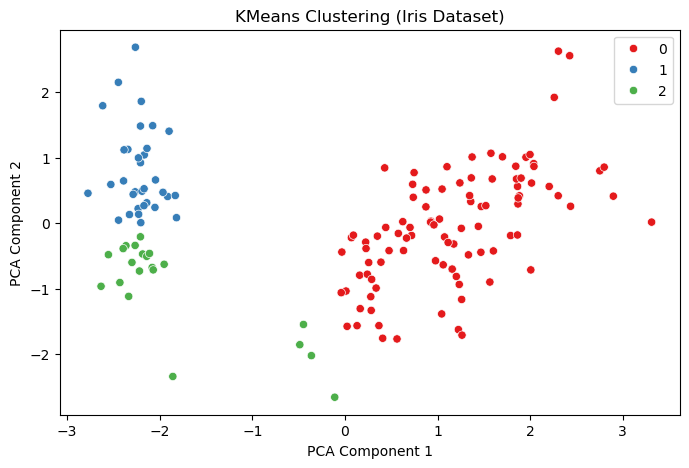

In [6]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette="Set1")
plt.title("KMeans Clustering (Iris Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

 **How KMeans Clustering Works :**  
KMeans is a partitioning algorithm that divides the dataset into K distinct non-overlapping clusters. It works as follows:

1. Choose the number of clusters K.

2. Randomly initialize K centroids.

3. Assign each point to the nearest centroid.

4. Update centroids as the mean of points in each cluster.

5. Repeat steps 3–4 until convergence.

**Why KMeans is Suitable for the Iris Dataset:**  

* Iris data has clearly defined clusters (species).

* KMeans is efficient for small to medium datasets.

* The dataset is numeric and low-dimensional, ideal for KMeans.

### Hierarchical Clustering

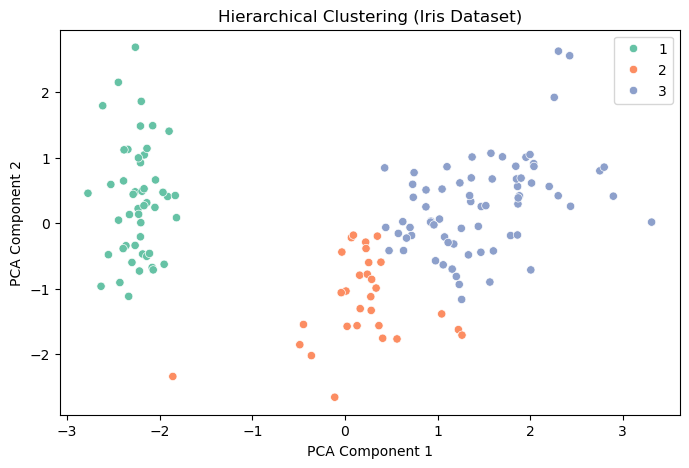

In [30]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Perform Hierarchical clustering
linked = linkage(X_scaled, method='ward')  # Ward minimizes variance

# Assign clusters (cutting the dendrogram at 3 clusters)
hierarchical_labels = fcluster(linked, 3, criterion='maxclust')

# Visualize clusters with PCA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hierarchical_labels, palette="Set2")
plt.title("Hierarchical Clustering (Iris Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

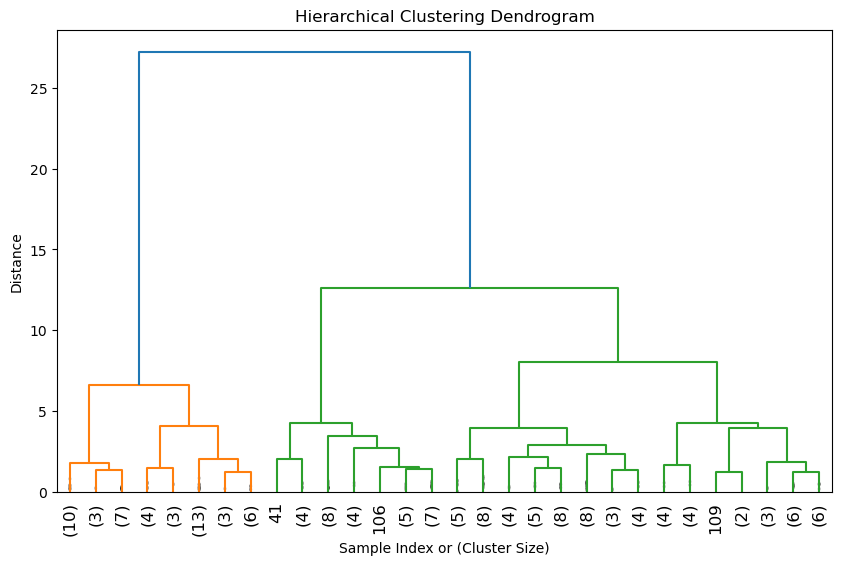

In [32]:
# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=12, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index or (Cluster Size)")
plt.ylabel("Distance")
plt.show()

**How Hierarchical Clustering Works:**  
Hierarchical clustering builds a hierarchy of clusters:

* Agglomerative (bottom-up): Start with individual points and merge closest pairs.

* Divisive (top-down): Start with one cluster and recursively split.

* Dendrograms help visualize the merging/splitting process.

**Why Hierarchical Clustering is Suitable for the Iris Dataset:**  
* Does not require predefining the number of clusters.

* Helpful in understanding data hierarchy.

* Works well with small datasets like Iris.

## Conclusion 
Both KMeans and Hierarchical Clustering effectively identified natural groupings in the Iris dataset without using labels.

* KMeans was fast and formed well-separated clusters.

* Hierarchical Clustering provided deeper insight through its dendrogram structure.

Both methods are suitable for small, well-structured datasets like Iris, each offering unique advantages.